# 📘 TESIS — Regime-Switching Adaptive Graph-Gated Network Markowitz (RS-AGGNM)

**Pengembangan Model Network Markowitz dengan Adaptive Graph Gating dan Regime-Switching untuk Optimasi Portofolio Kripto**

---

**Referensi Utama:**  
Giudici, P., Pagnottoni, P., & Polinesi, G. (2020). *Network Models to Enhance Automated Cryptocurrency Portfolio Management*. Frontiers in Artificial Intelligence, 3, 22.

---

## Struktur Notebook

| Sel | Konten |
|-----|--------|
| 1 | Library & Konfigurasi |
| 2 | Load & Validasi Data |
| 3 | Statistik Deskriptif (Table 1) |
| 4 | Visualisasi Harga Ternormalisasi (Figure 1 & 2) |
| 5 | MST Analysis — Bubble vs Stable (Figure 3 & 4) |
| 6 | MST Dynamics (Figure 5) |
| 7 | Helper Functions (RMT, MST, Centrality, Risk Metrics) |
| 8 | **[INOVASI 1]** Regime Detection via Gaussian HMM |
| 9 | **[INOVASI 2]** Graph Gating dengan OOS Theta Optimization |
| 10 | **[INOVASI 3]** RS-AGGNM — Model Utama Tesis |
| 11 | Semua Strategi Baseline (Replikasi + Fix Paper Asli) |
| 12 | Backtesting Framework (Turnover-based TC) |
| 13 | Eksekusi Backtesting Semua Strategi |
| 14 | Table 2 — Cumulative P&L |
| 15 | Table 3 — VaR 95% |
| 16 | Table 4 — Sharpe Ratio |
| 17 | Table 5 — Rachev Ratio |
| 18 | Table 6 — Market Phase Analysis |
| 19 | **[BARU]** Table 7 — Regime-Conditional Performance |
| 20 | Figure 6 — Cumulative Performance |
| 21 | **[BARU]** Figure 7 — RS-AGGNM vs Baselines |
| 22 | **[BARU]** Figure 8 — Regime Timeline & γ Adaptation |
| 23 | **[BARU]** Figure 9 — Portfolio Weights RS-AGGNM |
| 24 | Ringkasan Kontribusi Akademis |

---
## Sel 1 — Library & Konfigurasi Global

In [1]:
# ============================================================
# SEL 1 — LIBRARY & KONFIGURASI
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings

from scipy.stats import norm as stats_norm
from scipy.optimize import minimize
from scipy.linalg import eigh
from scipy.stats import norm
from sklearn.covariance import GraphicalLasso, LedoitWolf
from itertools import combinations

warnings.filterwarnings('ignore')

# ---------- Style ----------
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'font.family': 'DejaVu Sans'
})

# ---------- Seed ----------
np.random.seed(42)

# ---------- Global Params ----------
WINDOW_SIZE     = 120   # rolling window (hari)
REBALANCE_FREQ  = 7     # rebalancing (hari)
TRANS_COST      = 0.001 # 10 bps per turnover unit
VAR_CONF        = 0.95
RACHEV_ALPHA    = 0.10

print("✅ Libraries loaded successfully!")
print(f"   Window: {WINDOW_SIZE} days | Rebalance: {REBALANCE_FREQ} days | TC: {TRANS_COST*100:.1f} bps")

✅ Libraries loaded successfully!
   Window: 120 days | Rebalance: 7 days | TC: 0.1 bps


---
## Sel 2 — Load & Validasi Data

In [2]:
# ============================================================
# SEL 2 — LOAD DATA
# ============================================================
# ⚠️ [FIX 5 — Survivorship Bias]
# Dataset hanya mencakup aset yang bertahan hingga akhir periode.
# Aset yang kolaps/delisted tidak dimasukkan → performa semua strategi
# cenderung terlihat lebih baik dari kenyataan.
# Untuk penelitian lebih robust: gunakan dataset yang menyertakan aset gagal.

EXCEL_FILE = 'crypto_data_real.xlsx'  # ← Ganti path sesuai lokasi file

df_returns = pd.read_excel(EXCEL_FILE, sheet_name='Returns', index_col=0, parse_dates=True)
df_prices  = pd.read_excel(EXCEL_FILE, sheet_name='Prices',  index_col=0, parse_dates=True)

crypto_names = df_returns.columns.tolist()
N_ASSETS     = len(crypto_names)

print(f"✅ Data loaded: {df_returns.shape[0]} days × {N_ASSETS} assets")
print(f"   Period : {df_returns.index[0].date()} → {df_returns.index[-1].date()}")
print(f"   Assets : {crypto_names}")
print(f"   Missing: {df_returns.isnull().sum().sum()} values")

df_returns.dropna(inplace=True)

✅ Data loaded: 763 days × 10 assets
   Period : 2017-09-15 → 2019-10-17
   Assets : ['BTC', 'ETH', 'XRP', 'USDT', 'BCH', 'LTC', 'BNB', 'EOS', 'XLM', 'TRX']
   Missing: 0 values


---
## Sel 3 — Statistik Deskriptif (Table 1)

In [3]:
# ============================================================
# SEL 3 — TABLE 1: SUMMARY STATISTICS
# ============================================================
summary = pd.DataFrame({
    'Mean'    : df_returns.mean(),
    'Std'     : df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew(),
    'Min'     : df_returns.min(),
    'Max'     : df_returns.max(),
}).round(4)

print("TABLE 1 | Summary Statistics of Cryptocurrency Daily Returns")
print("="*70)
print(summary.to_string())
print("\nNote: All statistics computed over full sample period.")
print("      Non-zero kurtosis indicates heavy-tailed distributions → justifies RMT filtering.")

TABLE 1 | Summary Statistics of Cryptocurrency Daily Returns
        Mean     Std  Kurtosis  Skewness     Min     Max
BTC   0.0012  0.0434    3.0822    0.0523 -0.1846  0.2251
ETH  -0.0008  0.0507    2.8209   -0.2916 -0.2069  0.2347
XRP   0.0004  0.0654   18.9009    2.0588 -0.3520  0.6069
USDT -0.0000  0.0057   21.7209    0.7437 -0.0482  0.0566
BCH  -0.0014  0.0724    7.5671    0.6231 -0.4096  0.4316
LTC   0.0004  0.0585    6.6357    1.0988 -0.2119  0.3893
BNB   0.0029  0.0621   10.2612    1.0694 -0.3424  0.4818
EOS   0.0012  0.0709    4.7582    0.5781 -0.3015  0.3508
XLM   0.0006  0.0657    7.0332    0.9799 -0.3062  0.4618
TRX   0.0025  0.0879   22.1856    2.6905 -0.3579  0.7867

Note: All statistics computed over full sample period.
      Non-zero kurtosis indicates heavy-tailed distributions → justifies RMT filtering.


---
## Sel 4 — Visualisasi Harga Ternormalisasi (Figure 1 & 2)

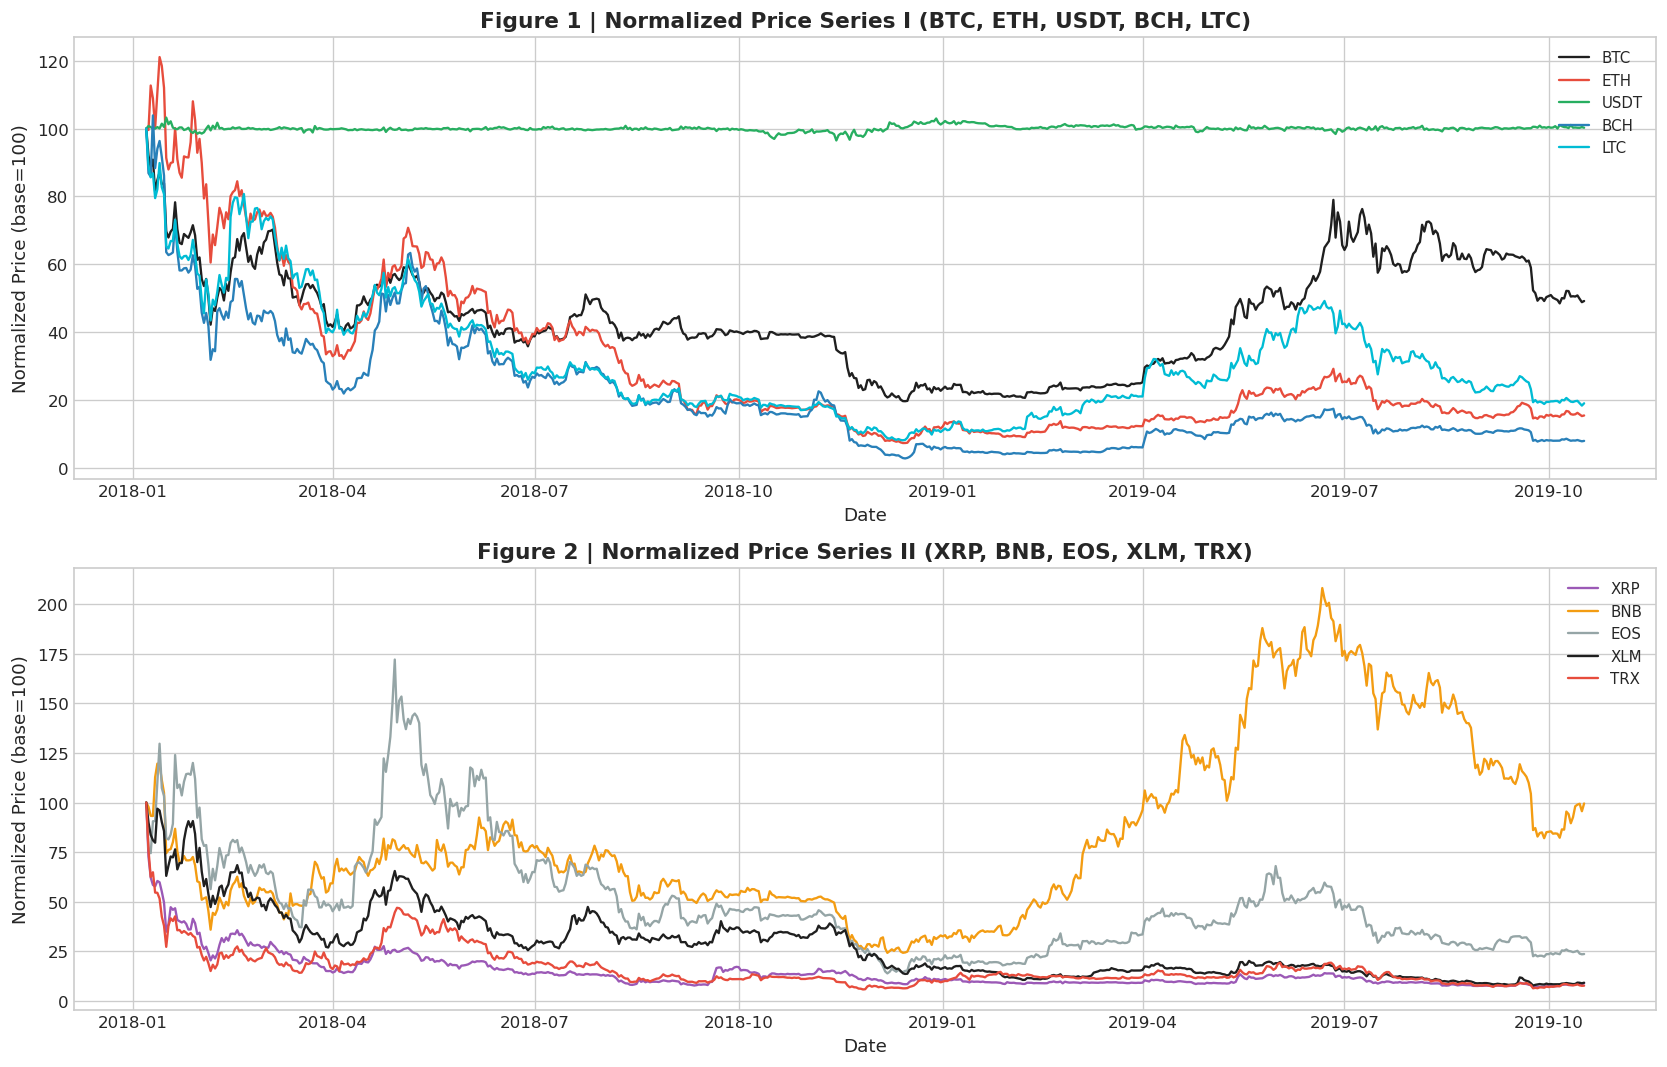

✅ Figure 1 & 2 saved.


In [4]:
# ============================================================
# SEL 4 — FIGURE 1 & 2: NORMALIZED PRICE SERIES
# ============================================================
START_NORM = '2018-01-07'
groups = [
    (['BTC','ETH','USDT','BCH','LTC'], ['#1f1f1f','#e74c3c','#27ae60','#2980b9','#00bcd4'],
     'Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)'),
    (['XRP','BNB','EOS','XLM','TRX'], ['#9b59b6','#f39c12','#95a5a6','#1f1f1f','#e74c3c'],
     'Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, (assets, colors, title) in zip(axes, groups):
    avail = [a for a in assets if a in df_prices.columns]
    base  = df_prices.loc[START_NORM:, avail]
    df_norm  = (base / base.iloc[0]) * 100
    for col, c in zip(df_norm.columns, colors):
        ax.plot(df_norm.index, df_norm[col], label=col, color=c, linewidth=1.4)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Normalized Price (base=100)')
    ax.legend(loc='upper right')
    ax.set_xlabel('Date')

plt.tight_layout()
plt.savefig('figure1_2_normalized_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 1 & 2 saved.")

---
## Sel 5 — MST Analysis: Bubble vs Stable Period (Figure 3 & 4)

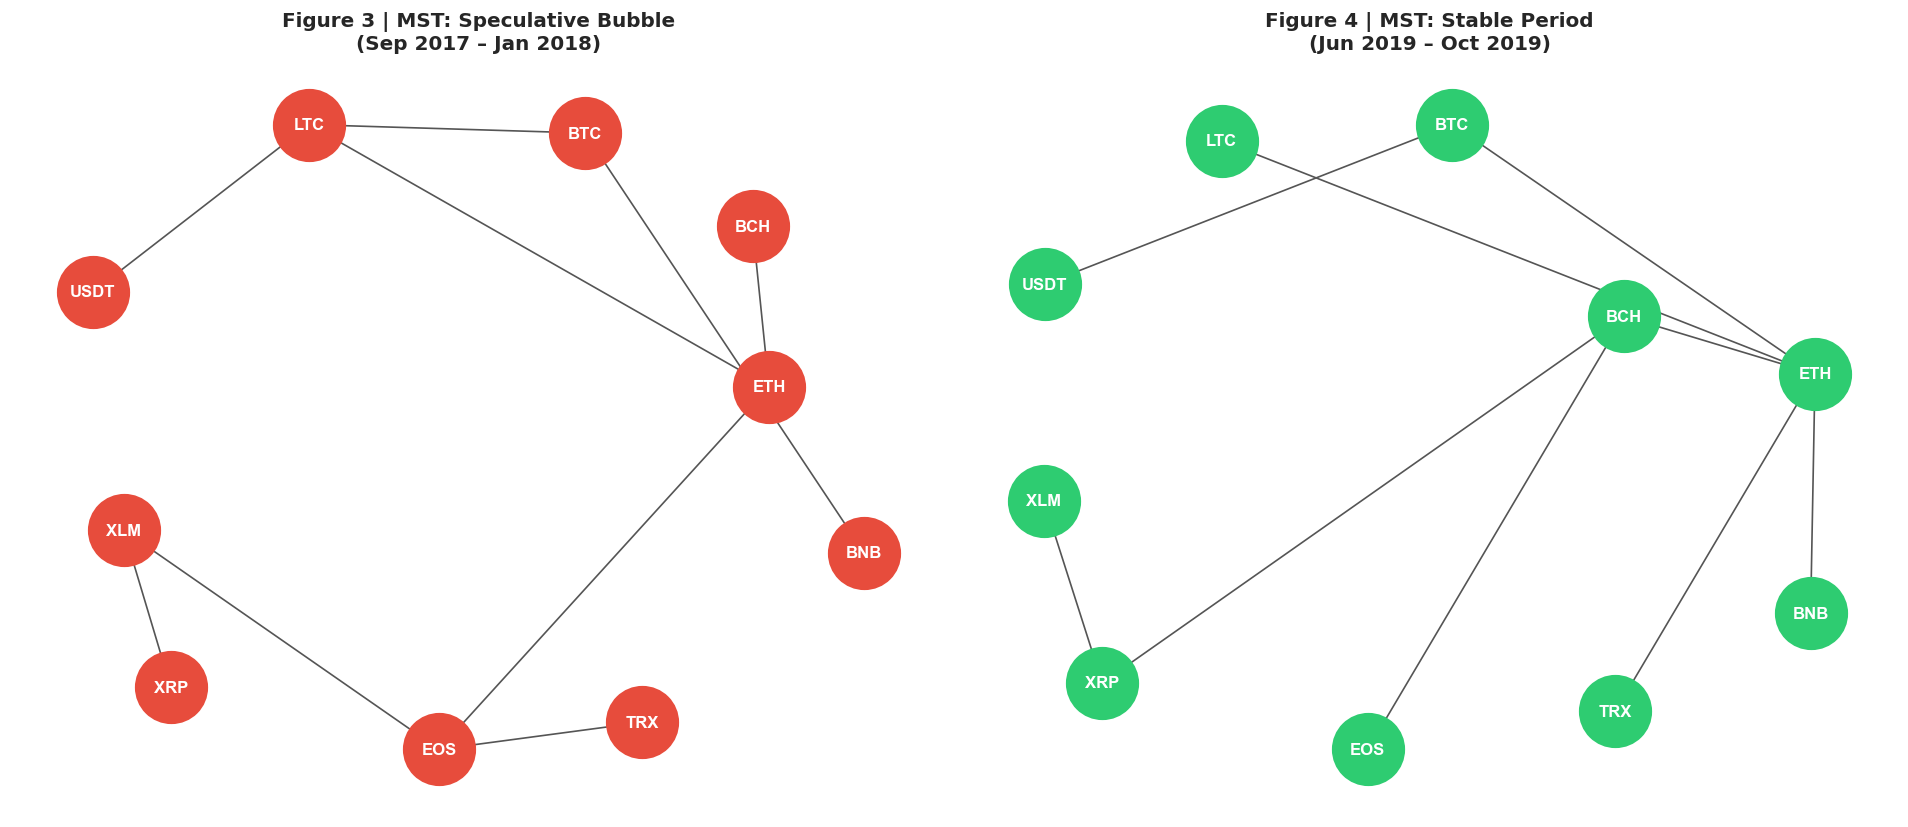

✅ Figure 3 & 4 saved.


In [5]:
# ============================================================
# SEL 5 — FIGURE 3 & 4: MST BUBBLE vs STABLE
# ============================================================
def build_and_draw_mst(returns_slice, title, ax, node_color='#F0A500'):
    corr = returns_slice.corr()
    dist = np.sqrt(2 * (1 - corr.clip(-1, 1)))
    np.fill_diagonal(dist.values, 0)
    G    = nx.from_pandas_adjacency(pd.DataFrame(dist.values,
               index=corr.index, columns=corr.columns))
    mst  = nx.minimum_spanning_tree(G, weight='weight')
    pos  = nx.spring_layout(mst, seed=42, k=2)
    nx.draw_networkx(mst, pos, ax=ax,
                     node_color=node_color, node_size=1800,
                     edge_color='#555', linewidths=1.5,
                     font_size=10, font_weight='bold', font_color='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')
    return mst

periods = [
    ('2017-09-14', '2018-01-31', 'Figure 3 | MST: Speculative Bubble\n(Sep 2017 – Jan 2018)', '#E74C3C'),
    ('2019-06-01', '2019-10-17', 'Figure 4 | MST: Stable Period\n(Jun 2019 – Oct 2019)',     '#2ECC71')
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (s, e, title, color) in zip(axes, periods):
    slice_ = df_returns.loc[s:e]
    build_and_draw_mst(slice_, title, ax, node_color=color)

plt.tight_layout()
plt.savefig('figure3_4_mst_periods.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 3 & 4 saved.")

---
## Sel 6 — MST Dynamics: Max Link & Residuality (Figure 5)

⏳ Computing MST dynamics (this may take ~1 minute)...


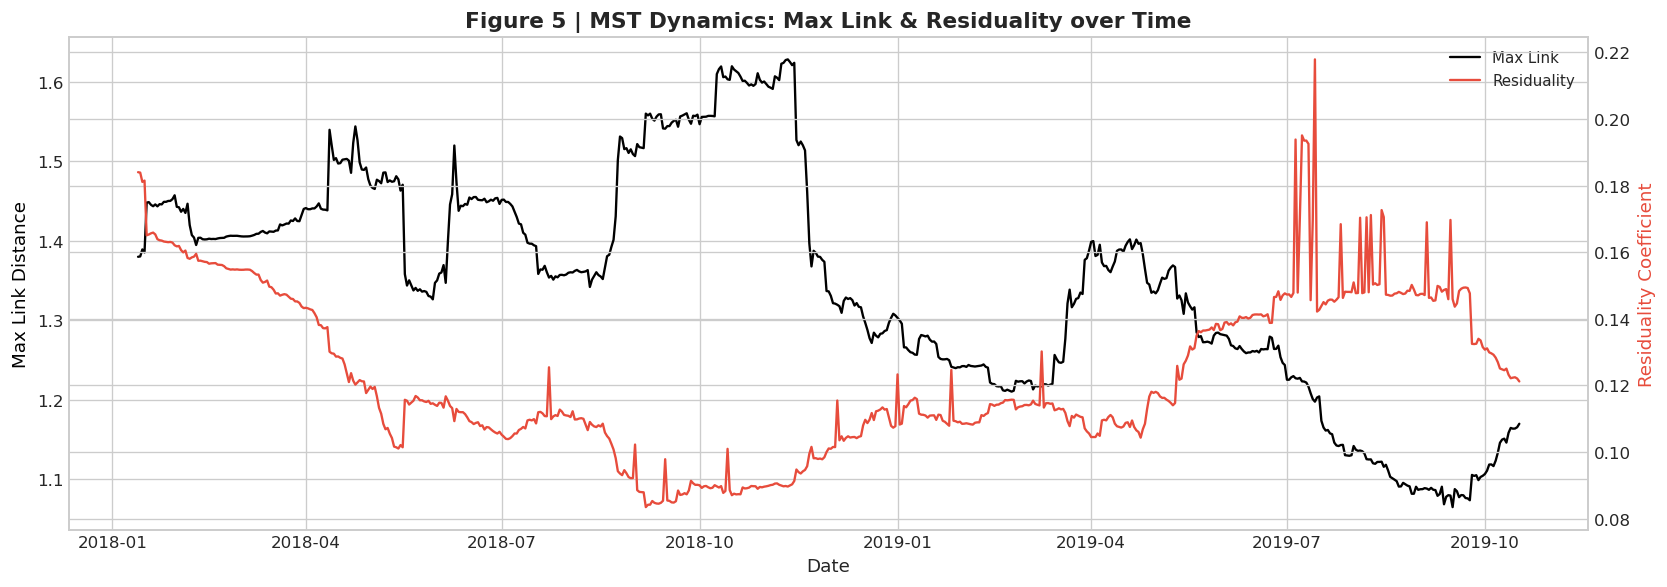

✅ Figure 5 saved.


In [6]:
# ============================================================
# SEL 6 — FIGURE 5: MST DYNAMICS OVER TIME
# ============================================================
def apply_rmt_filter(returns_data):
    """Filter noise dari matriks korelasi menggunakan Random Matrix Theory."""
    data = returns_data.values if isinstance(returns_data, pd.DataFrame) else returns_data
    T, N = data.shape
    Q    = T / N
    C    = np.corrcoef(data.T)
    eigenvalues, eigenvectors = eigh(C)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]
    lambda_plus  = (1 + np.sqrt(1/Q))**2
    sig_mask     = eigenvalues > lambda_plus
    Lam          = np.diag(np.where(sig_mask, eigenvalues, 0))
    C_filtered   = eigenvectors @ Lam @ eigenvectors.T
    return C_filtered

def calculate_rolling_mst_metrics(returns_df, window=120):
    dates, max_links, residualities = [], [], []
    for i in range(window, len(returns_df)):
        w     = returns_df.iloc[i-window:i]
        Cf    = apply_rmt_filter(w)
        dist  = np.sqrt(np.clip(2 - 2*Cf, 0, None))
        np.fill_diagonal(dist, 0)
        max_links.append(np.max(dist))
        G   = nx.from_numpy_array(dist)
        mst = nx.minimum_spanning_tree(G, weight='weight')
        L   = max(d['weight'] for _,_,d in mst.edges(data=True))
        inv_above = sum(1/dist[i,j] for i,j in combinations(range(dist.shape[0]),2) if dist[i,j]>L and dist[i,j]>0)
        inv_below = sum(1/dist[i,j] for i,j in combinations(range(dist.shape[0]),2) if 0<dist[i,j]<=L)
        residualities.append(inv_above / inv_below if inv_below > 0 else 0)
        dates.append(returns_df.index[i])
    return pd.DataFrame({'Max Link': max_links, 'Residuality': residualities}, index=dates)

print("⏳ Computing MST dynamics (this may take ~1 minute)...")
mst_dyn = calculate_rolling_mst_metrics(df_returns)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(mst_dyn.index, mst_dyn['Max Link'], color='black', label='Max Link', linewidth=1.4)
ax1.set_ylabel('Max Link Distance', color='black')
ax1.set_xlabel('Date')
ax2 = ax1.twinx()
ax2.plot(mst_dyn.index, mst_dyn['Residuality'], color='#E74C3C', label='Residuality', linewidth=1.4)
ax2.set_ylabel('Residuality Coefficient', color='#E74C3C')
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper right')
plt.title('Figure 5 | MST Dynamics: Max Link & Residuality over Time', fontweight='bold')
plt.tight_layout()
plt.savefig('figure5_mst_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 5 saved.")

---
## Sel 7 — Helper Functions

In [7]:
# ============================================================
# SEL 7 — HELPER FUNCTIONS
# ============================================================

def build_distance_matrix(corr_matrix):
    """Hitung matriks jarak Euclidean dari matriks korelasi."""
    dist = np.sqrt(np.clip(2 - 2*corr_matrix, 0, None))
    np.fill_diagonal(dist, 0)
    return dist

def compute_eigenvector_centrality(distance_matrix):
    """Hitung eigenvector centrality dari matriks jarak."""
    adj  = 1.0 / (distance_matrix + 1e-8)
    np.fill_diagonal(adj, 0)
    _, vecs = eigh(adj)
    pev     = np.abs(vecs[:, -1])
    return pev / pev.sum()

def calculate_var(returns, confidence=0.95):
    """Value at Risk (historical simulation)."""
    return np.percentile(returns, (1 - confidence) * 100)

def calculate_rachev_ratio(returns, alpha=0.10):
    """Rachev Ratio: CVaR_upper / |CVaR_lower|."""
    up   = np.percentile(returns, (1 - alpha) * 100)
    lo   = np.percentile(returns, alpha * 100)
    cvu  = returns[returns >= up].mean()
    cvl  = abs(returns[returns <= lo].mean())
    return cvu / cvl if cvl > 0 else 0

def calculate_max_drawdown(cum_returns):
    """Maximum Drawdown dari cumulative return series."""
    peak = np.maximum.accumulate(cum_returns)
    dd   = (cum_returns - peak) / peak
    return dd.min()

def calculate_calmar_ratio(returns, cum_returns):
    """Calmar Ratio = Annualized Return / |Max Drawdown|."""
    ann_ret = np.mean(returns) * 252
    mdd     = abs(calculate_max_drawdown(cum_returns))
    return ann_ret / mdd if mdd > 0 else 0

def get_mis_assets(returns_window, corr_threshold=0.4):
    """Maximum Independent Set (MIS) untuk graph diversification.
    [FIX 3] Gunakan korelasi empiris biasa (bukan nested CV)."""
    corr   = returns_window.corr()
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G      = nx.Graph()
    G.add_nodes_from(assets)
    for a1, a2 in combinations(assets, 2):
        if abs(corr.loc[a1, a2]) > corr_threshold:
            G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

def get_mis_assets_rmt(returns_window, corr_threshold=0.4):
    """MIS berbasis korelasi yang sudah difilter RMT."""
    assets = returns_window.columns.tolist()
    Cf     = apply_rmt_filter(returns_window)
    G      = nx.Graph()
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for j, a2 in enumerate(assets):
            if i < j and abs(Cf[i, j]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))

print("✅ Helper functions defined.")

✅ Helper functions defined.


---
## Sel 8 — [INOVASI 1] Regime Detection via Gaussian HMM

> **Kontribusi Tesis:** Paper asli (Giudici et al., 2020) menggunakan γ tetap yang dipilih secara manual.  
> Model ini mendeteksi regime pasar (Bull/Bear) secara otomatis menggunakan Hidden Markov Model,  
> sehingga γ dapat diadaptasi secara data-driven.

⏳ Fitting Gaussian HMM on volatility proxy...

✅ HMM fitted successfully!
   Bull (Low-Vol)  State μ=0.0243, σ=0.0056 → 580 days (78.1%)
   Bear (High-Vol) State μ=0.0618, σ=0.0289 → 163 days (21.9%)


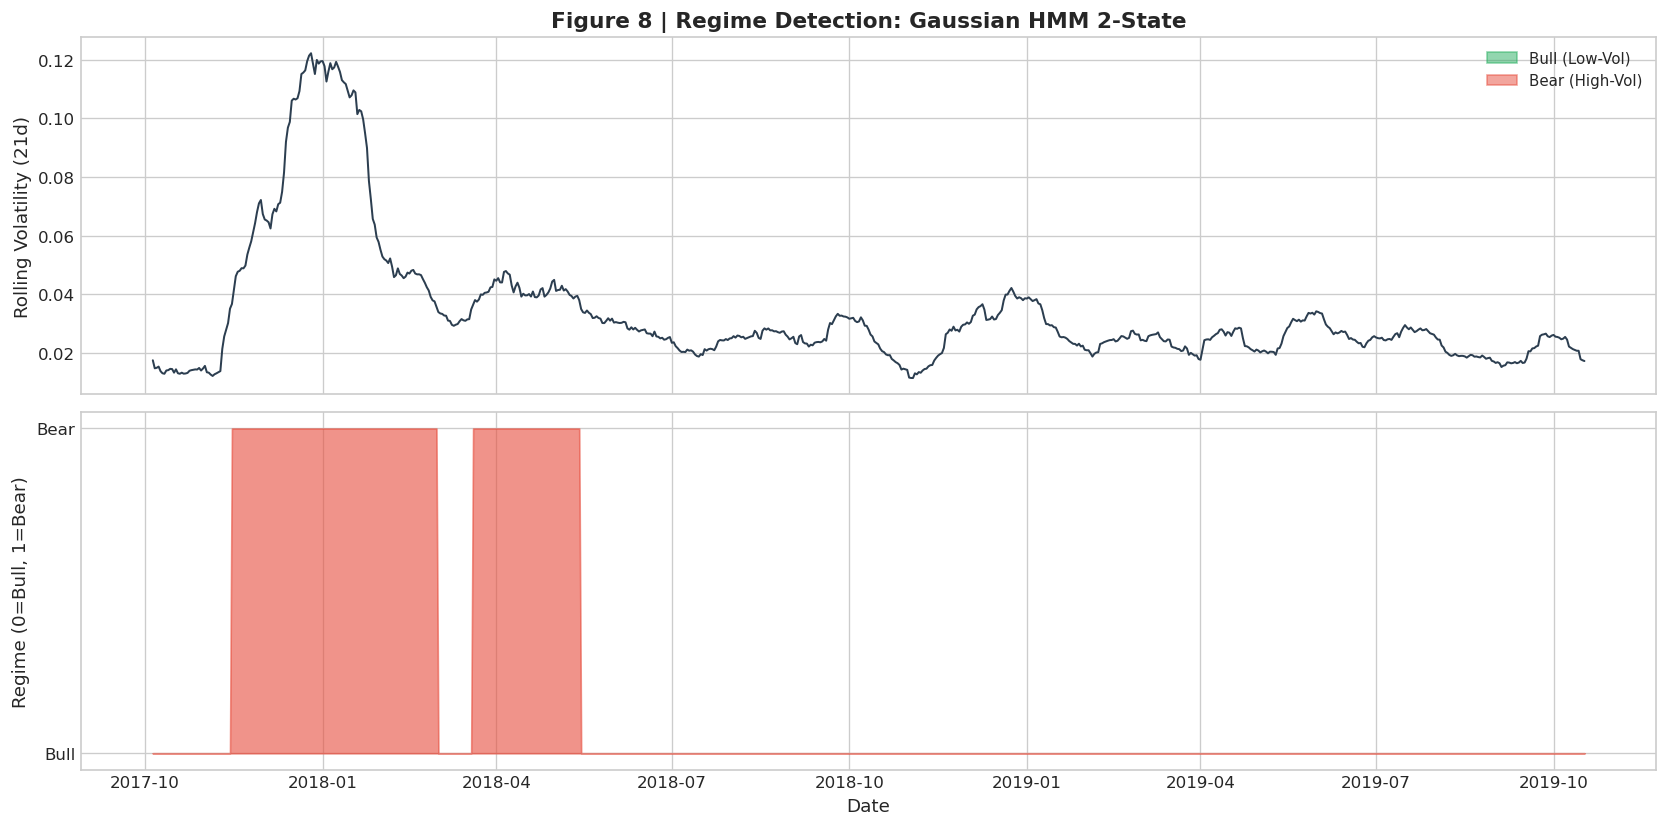

In [8]:
# ============================================================
# SEL 8 — [INOVASI 1] REGIME DETECTION VIA GAUSSIAN HMM
# ============================================================
# Implementasi Gaussian HMM 2-state dari scratch menggunakan
# Baum-Welch algorithm (EM) — tanpa dependency eksternal

class GaussianHMM2State:
    """
    Hidden Markov Model 2-state dengan emisi Gaussian.
    State 0 = Low Volatility (Bull)
    State 1 = High Volatility (Bear)
    
    Implementasi Baum-Welch (EM) dari scratch.
    Digunakan sebagai Regime Detector untuk RS-AGGNM.
    """
    def __init__(self, n_iter=100, tol=1e-4, random_state=42):
        self.n_iter       = n_iter
        self.tol          = tol
        self.random_state = random_state
        self.pi_   = None  # initial state prob
        self.A_    = None  # transition matrix
        self.mu_   = None  # emission means
        self.sig_  = None  # emission stds

    def _init_params(self, X):
        rng = np.random.RandomState(self.random_state)
        self.pi_ = np.array([0.5, 0.5])
        self.A_  = np.array([[0.95, 0.05], [0.05, 0.95]])
        # Initialize means via k-means-like split
        sorted_X = np.sort(X)
        mid      = len(sorted_X) // 2
        self.mu_  = np.array([sorted_X[:mid].mean(), sorted_X[mid:].mean()])
        self.sig_ = np.array([sorted_X[:mid].std() + 1e-6,
                               sorted_X[mid:].std() + 1e-6])

    #def _emission(self, X, k):
    #    return norm.pdf(X, loc=self.mu_[k], scale=self.sig_[k]) + 1e-300

    def _emission(self, X, k):
        # Gunakan stats_norm yang baru saja di-alias
        return stats_norm.pdf(X, loc=self.mu_[k], scale=self.sig_[k]) + 1e-300


    def _forward(self, X):
        T    = len(X)
        alpha = np.zeros((T, 2))
        c     = np.zeros(T)
        alpha[0] = self.pi_ * np.array([self._emission(X[0], k) for k in range(2)])
        c[0]     = alpha[0].sum()
        alpha[0] /= c[0]
        for t in range(1, T):
            for j in range(2):
                alpha[t, j] = (alpha[t-1] @ self.A_[:, j]) * self._emission(X[t], j)
            c[t] = alpha[t].sum()
            alpha[t] /= c[t]
        return alpha, c

    def _backward(self, X, c):
        T    = len(X)
        beta = np.zeros((T, 2))
        beta[-1] = 1.0
        for t in range(T-2, -1, -1):
            for i in range(2):
                beta[t, i] = sum(self.A_[i, j] * self._emission(X[t+1], j) * beta[t+1, j]
                                 for j in range(2))
            beta[t] /= c[t+1]
        return beta

    def fit(self, X):
        X = np.asarray(X).flatten()
        self._init_params(X)
        prev_ll = -np.inf
        for _ in range(self.n_iter):
            # E-step
            alpha, c = self._forward(X)
            beta      = self._backward(X, c)
            T         = len(X)
            gamma     = alpha * beta
            gamma    /= gamma.sum(axis=1, keepdims=True)
            xi        = np.zeros((T-1, 2, 2))
            for t in range(T-1):
                for i in range(2):
                    for j in range(2):
                        xi[t,i,j] = (alpha[t,i] * self.A_[i,j] *
                                     self._emission(X[t+1], j) * beta[t+1,j])
                xi[t] /= xi[t].sum()
            # M-step
            self.pi_ = gamma[0]
            self.A_  = xi.sum(0) / xi.sum(0).sum(1, keepdims=True)
            for k in range(2):
                g         = gamma[:, k]
                self.mu_[k]  = (g * X).sum() / g.sum()
                self.sig_[k] = np.sqrt((g * (X - self.mu_[k])**2).sum() / g.sum()) + 1e-6
            # Convergence
            ll = np.log(c).sum()
            if abs(ll - prev_ll) < self.tol:
                break
            prev_ll = ll
        return self

    def predict(self, X):
        """Viterbi decoding untuk sequence state terbaik."""
        X  = np.asarray(X).flatten()
        T  = len(X)
        delta   = np.zeros((T, 2))
        psi     = np.zeros((T, 2), dtype=int)
        delta[0] = self.pi_ * np.array([self._emission(X[0], k) for k in range(2)])
        for t in range(1, T):
            for j in range(2):
                scores    = delta[t-1] * self.A_[:, j]
                psi[t, j] = np.argmax(scores)
                delta[t,j] = scores[psi[t,j]] * self._emission(X[t], j)
        states    = np.zeros(T, dtype=int)
        states[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]
        # Ensure state 0 = low vol (Bull), state 1 = high vol (Bear)
        if self.sig_[0] > self.sig_[1]:
            states = 1 - states
            self.mu_  = self.mu_[::-1].copy()
            self.sig_ = self.sig_[::-1].copy()
        return states

    def predict_proba(self, X):
        """Posterior probabilities via forward algorithm."""
        alpha, _ = self._forward(np.asarray(X).flatten())
        return alpha


# ---- Fit HMM pada proxy volatilitas (rolling std return) ----
VOL_PROXY = df_returns.std(axis=1).rolling(21).mean().dropna()

print("⏳ Fitting Gaussian HMM on volatility proxy...")
hmm_model  = GaussianHMM2State(n_iter=200, tol=1e-5)
hmm_model.fit(VOL_PROXY.values)
regime_seq = hmm_model.predict(VOL_PROXY.values)
regime_series = pd.Series(regime_seq, index=VOL_PROXY.index,
                           name='Regime')  # 0=Bull, 1=Bear

# ---- Summary ----
n_bull = (regime_series == 0).sum()
n_bear = (regime_series == 1).sum()
print(f"\n✅ HMM fitted successfully!")
print(f"   Bull (Low-Vol)  State μ={hmm_model.mu_[0]:.4f}, σ={hmm_model.sig_[0]:.4f} → {n_bull} days ({100*n_bull/len(regime_series):.1f}%)")
print(f"   Bear (High-Vol) State μ={hmm_model.mu_[1]:.4f}, σ={hmm_model.sig_[1]:.4f} → {n_bear} days ({100*n_bear/len(regime_series):.1f}%)")

# ---- Visualisasi Regime ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(VOL_PROXY.index, VOL_PROXY.values, color='#2c3e50', linewidth=1.2)
for idx in VOL_PROXY.index:
    r = regime_series.get(idx, 0)
    ax1.axvspan(idx, idx, alpha=0.3,
                color='#E74C3C' if r == 1 else '#27AE60', linewidth=0)
ax1.set_ylabel('Rolling Volatility (21d)')
ax1.set_title('Figure 8 | Regime Detection: Gaussian HMM 2-State', fontweight='bold')
bull_patch = mpatches.Patch(color='#27AE60', alpha=0.5, label='Bull (Low-Vol)')
bear_patch = mpatches.Patch(color='#E74C3C', alpha=0.5, label='Bear (High-Vol)')
ax1.legend(handles=[bull_patch, bear_patch], loc='upper right')

ax2.fill_between(regime_series.index, regime_series.values,
                 color='#E74C3C', alpha=0.6, label='Bear Regime')
ax2.set_ylabel('Regime (0=Bull, 1=Bear)')
ax2.set_xlabel('Date')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Bull', 'Bear'])

plt.tight_layout()
plt.savefig('figure8_regime_detection.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sel 9 — [INOVASI 2] Graph Gating dengan OOS Theta Optimization

> **Kontribusi Tesis:** Mengintegrasikan Maximum Independent Set (MIS) sebagai constraint eksplisit  
> dalam optimasi Network Markowitz, dengan θ yang dioptimasi secara OOS (tanpa data leakage).

In [9]:
# ============================================================
# SEL 9 — [INOVASI 2] GRAPH GATING + OOS THETA OPTIMIZATION
# ============================================================

def optimize_theta_oos(prior_returns, min_history=60):
    """
    [FIX 3 — No Data Leakage]
    Optimasi threshold θ menggunakan data prior (benar-benar OOS).
    Split 70/30 dari data prior untuk train/val.
    """
    if prior_returns is None or len(prior_returns) < min_history:
        return 0.4  # default
    best_theta, max_sharpe = 0.4, -np.inf
    split = int(0.7 * len(prior_returns))
    for theta in np.arange(0.2, 0.8, 0.1):
        train = prior_returns.iloc[:split]
        val   = prior_returns.iloc[split:]
        sel   = get_mis_assets(train, theta)
        if not sel:
            continue
        n  = train.shape[1]
        w  = np.zeros(n)
        for a in sel:
            if a in train.columns:
                w[train.columns.tolist().index(a)] = 1.0 / len(sel)
        vr = val.dot(w)
        sr = vr.mean() / vr.std() if vr.std() > 1e-6 else 0
        if sr > max_sharpe:
            max_sharpe = sr
            best_theta = theta
    return round(best_theta, 1)


def graph_gate(returns_window, theta, use_rmt=True):
    """
    Seleksi aset via MIS dari filtered correlation graph.
    Returns: list of selected assets, weight vector (equal-weight on selected)
    """
    n      = returns_window.shape[1]
    assets = returns_window.columns.tolist()
    sel    = get_mis_assets_rmt(returns_window, theta) if use_rmt \
             else get_mis_assets(returns_window, theta)
    if not sel:
        sel = assets  # fallback: semua aset
    return sel


print("✅ Graph Gating functions defined.")
print("   optimize_theta_oos() — expanding OOS theta optimization (no leakage)")
print("   graph_gate()         — MIS-based asset selection gate")

✅ Graph Gating functions defined.
   optimize_theta_oos() — expanding OOS theta optimization (no leakage)
   graph_gate()         — MIS-based asset selection gate


---
## Sel 10 — [INOVASI 3] RS-AGGNM — Model Utama Tesis

> **Regime-Switching Adaptive Graph-Gated Network Markowitz**
> 
> Formulas:
> $$\min_w \; w^\top \Sigma^* w + \gamma_t \sum_{i \in S^*} x_i w_i$$
> 
> Subject to: $\sum w_i = 1$, $w_i \geq 0$, $w_i = 0 \; \forall i \notin S^*$, $w^\top \mu \geq \mu_{max} \times 0.5$
> 
> where $\gamma_t = \gamma_{bear}$ if $\text{regime}_t = \text{Bear}$, else $\gamma_{bull}$

In [10]:
# ============================================================
# SEL 10 — [INOVASI 3] RS-AGGNM MODEL
# ============================================================

class PortfolioStrategy:
    def __init__(self, name):
        self.name = name
    def get_weights(self, returns_data, **kwargs):
        raise NotImplementedError


# ──────────────────────────────────────────────────────────────
# BASELINE 1: Equally Weighted
# ──────────────────────────────────────────────────────────────
class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, r, **kwargs):
        return np.ones(r.shape[1]) / r.shape[1]


# ──────────────────────────────────────────────────────────────
# BASELINE 2: Classical Markowitz [FIX 6]
# ──────────────────────────────────────────────────────────────
class ClassicalMarkowitz(PortfolioStrategy):
    """[FIX 6] Return constraint: w@mu >= mu_max*0.5"""
    def get_weights(self, r, **kwargs):
        n, mu, S = r.shape[1], r.mean().values, r.cov().values
        min_ret  = mu.max() * 0.5
        res = minimize(lambda w: w @ S @ w, np.ones(n)/n, method='SLSQP',
                       bounds=[(0,1)]*n,
                       constraints=[{'type':'eq',  'fun': lambda w: w.sum()-1},
                                    {'type':'ineq','fun': lambda w: w@mu - min_ret}])
        return res.x if res.success else np.ones(n)/n


# ──────────────────────────────────────────────────────────────
# BASELINE 3: Glasso Markowitz [FIX 1, FIX 6]
# ──────────────────────────────────────────────────────────────
class GlassoMarkowitz(PortfolioStrategy):
    """[FIX 1] Fixed alpha — no lookahead bias from CV.
       [FIX 6] Strengthened return constraint."""
    def __init__(self, name='Glasso Markowitz', alpha=0.1):
        super().__init__(name)
        self.alpha = alpha
    def get_weights(self, r, **kwargs):
        n, mu = r.shape[1], r.mean().values
        try:
            gl = GraphicalLasso(alpha=self.alpha, max_iter=500)
            gl.fit(r.values)
            S  = gl.covariance_
        except:
            S  = r.cov().values
        min_ret = mu.max() * 0.5
        res = minimize(lambda w: w @ S @ w, np.ones(n)/n, method='SLSQP',
                       bounds=[(0,1)]*n,
                       constraints=[{'type':'eq',  'fun': lambda w: w.sum()-1},
                                    {'type':'ineq','fun': lambda w: w@mu - min_ret}])
        return res.x if res.success else np.ones(n)/n


# ──────────────────────────────────────────────────────────────
# BASELINE 4: Network Markowitz (Paper Asli) [FIX 6]
# ──────────────────────────────────────────────────────────────
class NetworkMarkowitz(PortfolioStrategy):
    """Replikasi model Giudici et al. (2020) dengan FIX 6."""
    def __init__(self, name='NW', gamma=0.0):
        super().__init__(name)
        self.gamma = gamma
    def get_weights(self, r, **kwargs):
        n, mu, sig = r.shape[1], r.mean().values, r.std().values
        Cf   = apply_rmt_filter(r)
        dist = build_distance_matrix(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf
        min_ret = mu.max() * 0.5
        res = minimize(lambda w: w @ Sf @ w + self.gamma * (cent * w).sum(),
                       np.ones(n)/n, method='SLSQP',
                       bounds=[(0,1)]*n,
                       constraints=[{'type':'eq',  'fun': lambda w: w.sum()-1},
                                    {'type':'ineq','fun': lambda w: w@mu - min_ret}])
        return res.x if res.success else np.ones(n)/n


# ──────────────────────────────────────────────────────────────
# BASELINE 5: Graph Diversification (MIS)
# ──────────────────────────────────────────────────────────────
class GraphDiversification(PortfolioStrategy):
    def __init__(self, name='Graph Divers.', theta=0.4):
        super().__init__(name)
        self.theta = theta
    def get_weights(self, r, **kwargs):
        n, assets = r.shape[1], r.columns.tolist()
        sel = get_mis_assets(r, self.theta)
        w   = np.zeros(n)
        for a in (sel or assets):
            w[assets.index(a)] = 1.0 / len(sel or assets)
        return w


# ──────────────────────────────────────────────────────────────
# BASELINE 6: RMT Graph Diversification
# ──────────────────────────────────────────────────────────────
class RMTGraphDiversification(PortfolioStrategy):
    def __init__(self, name='RMT GD', theta=0.4):
        super().__init__(name)
        self.theta = theta
    def get_weights(self, r, **kwargs):
        n, assets = r.shape[1], r.columns.tolist()
        sel = get_mis_assets_rmt(r, self.theta)
        w   = np.zeros(n)
        for a in (sel or assets):
            w[assets.index(a)] = 1.0 / len(sel or assets)
        return w


# ══════════════════════════════════════════════════════════════
# ★★★ MODEL UTAMA TESIS: RS-AGGNM ★★★
# ══════════════════════════════════════════════════════════════
class RS_AGGNM(PortfolioStrategy):
    """
    Regime-Switching Adaptive Graph-Gated Network Markowitz
    ========================================================
    KONTRIBUSI TESIS:
    
    [INOVASI 1] Regime Detection:
        γ_t diadaptasi otomatis berdasarkan regime yang dideteksi HMM.
        - Bull regime → γ_bull (lebih agresif, masuk aset sentral)
        - Bear regime → γ_bear (lebih defensif, hindari aset sentral)
    
    [INOVASI 2] Graph Gating:
        S* = MIS(G(C*_t, θ*_OOS)) — seleksi aset via Maximum Independent Set
        Hanya aset dalam S* yang dimasukkan dalam optimasi (w_i=0 jika i∉S*).
        θ* dioptimasi via expanding OOS (no data leakage).
    
    [INOVASI 3] Integrasi:
        min_w  w^T Σ* w + γ_t Σ_{i∈S*}(x_i w_i)
        s.t.   Σw_i=1, w_i≥0, w_i=0 ∀i∉S*, w^Tμ ≥ μ_max×0.5
    
    Parameters
    ----------
    gamma_bull : float, γ saat Bull regime (default 0.7 — agresif)
    gamma_bear : float, γ saat Bear regime (default 0.0 — defensif)
    use_ledoit  : bool, gunakan Ledoit-Wolf shrinkage (True) atau RMT (False)
    hmm_model   : fitted GaussianHMM2State instance
    regime_series: pd.Series dengan index tanggal dan nilai 0/1
    """
    def __init__(self, name='RS-AGGNM',
                 gamma_bull=0.5, gamma_bear=0.05,
                 use_ledoit=False,
                 hmm_model=None, regime_series=None):
        super().__init__(name)
        self.gamma_bull    = gamma_bull
        self.gamma_bear    = gamma_bear
        self.use_ledoit    = use_ledoit
        self.hmm_model     = hmm_model
        self.regime_series = regime_series

    def _detect_regime(self, returns_window):
        """Deteksi regime dari tail of window — proxy current regime."""
        if self.regime_series is not None:
            # Gunakan regime terakhir yang diketahui di akhir window
            last_date = returns_window.index[-1]
            avail = self.regime_series.index[self.regime_series.index <= last_date]
            if len(avail) > 0:
                return int(self.regime_series.loc[avail[-1]])
        # Fallback: regime berbasis volatilitas rolling
        vol = returns_window.std(axis=1).mean()
        global_vol = df_returns.std(axis=1).mean()
        return 1 if vol > global_vol else 0

    def get_weights(self, r, prior_returns=None, theta=0.4, **kwargs):
        n      = r.shape[1]
        assets = r.columns.tolist()
        mu     = r.mean().values
        sig    = r.std().values

        # ── [INOVASI 1] Regime Detection → Adaptive γ ──
        regime  = self._detect_regime(r)
        gamma_t = self.gamma_bear if regime == 1 else self.gamma_bull

        # ── [INOVASI 2] Graph Gating ──
        sel = get_mis_assets_rmt(r, theta)
        if not sel:
            sel = assets
        sel_idx = [assets.index(a) for a in sel]

        # ── Covariance Estimation ──
        if self.use_ledoit:
            lw = LedoitWolf().fit(r.values)
            Cf_full = lw.covariance_
            Sf = Cf_full
        else:
            Cf   = apply_rmt_filter(r)
            Sf   = np.outer(sig, sig) * Cf
            dist = build_distance_matrix(Cf)

        # ── Eigenvector Centrality (pada subgraph S*) ──
        dist_sub = build_distance_matrix(apply_rmt_filter(r.iloc[:, sel_idx]))
        cent_sub = compute_eigenvector_centrality(dist_sub)

        # ── [INOVASI 3] Optimasi dengan Graph Gating Constraint ──
        n_sel    = len(sel)
        Sf_sub   = Sf[np.ix_(sel_idx, sel_idx)]
        mu_sub   = mu[sel_idx]
        min_ret  = mu.max() * 0.5  # [FIX 6]

        def objective(w_sub):
            return w_sub @ Sf_sub @ w_sub + gamma_t * (cent_sub * w_sub).sum()

        res = minimize(objective, np.ones(n_sel)/n_sel, method='SLSQP',
                       bounds=[(0,1)]*n_sel,
                       constraints=[
                           {'type':'eq',  'fun': lambda w: w.sum() - 1},
                           {'type':'ineq','fun': lambda w: w @ mu_sub - min_ret}
                       ])
        w_sub = res.x if res.success else np.ones(n_sel)/n_sel

        # ── Map ke full weight vector ──
        w_full = np.zeros(n)
        for i, idx in enumerate(sel_idx):
            w_full[idx] = w_sub[i]

        return w_full, regime, gamma_t, sel


print("✅ All portfolio strategy classes defined!")
print("")
print("   Baselines : EW, CM, GM, NW(γ=0), NW(γ=0.05), NW(γ=0.15), NW(γ=0.7)")
print("              Graph Divers.(θ=0.4), Graph Divers.(θ=0.5), RMT GD(θ=0.4)")
print("   ★ Model  : RS-AGGNM (Kontribusi Utama Tesis)")

✅ All portfolio strategy classes defined!

   Baselines : EW, CM, GM, NW(γ=0), NW(γ=0.05), NW(γ=0.15), NW(γ=0.7)
              Graph Divers.(θ=0.4), Graph Divers.(θ=0.5), RMT GD(θ=0.4)
   ★ Model  : RS-AGGNM (Kontribusi Utama Tesis)


---
## Sel 11 — Backtesting Framework

In [11]:
# ============================================================
# SEL 11 — BACKTESTING FRAMEWORK
# ============================================================
# [FIX 4] Transaction cost berbasis turnover (bukan flat):
#   TC = TRANS_COST × Σ|w_baru - w_lama|
# [FIX 3] Prior returns diteruskan ke OOS theta optimization

def backtest_strategy(strategy, df_ret,
                      window_size=WINDOW_SIZE,
                      rebalance_freq=REBALANCE_FREQ,
                      tc=TRANS_COST,
                      verbose=False):
    """
    Rolling window backtesting dengan turnover-based transaction cost.
    
    Returns dict dengan:
    - returns          : np.array daily returns
    - cumulative_returns: np.array cumulative P&L
    - results_df       : pd.DataFrame dengan date, return, cumret
    - regime_log       : list of (date, regime, gamma, selected_assets) — RS-AGGNM only
    - weights_log      : list of (date, weights)
    """
    portfolio_returns = []
    dates             = []
    regime_log        = []
    weights_log       = []
    prev_weights      = None

    for i in range(window_size, len(df_ret), rebalance_freq):
        train    = df_ret.iloc[i - window_size : i]
        test_end = min(i + rebalance_freq, len(df_ret))
        test     = df_ret.iloc[i : test_end]
        if len(test) == 0:
            continue

        # ── Compute Weights ──
        if isinstance(strategy, RS_AGGNM):
            prior = df_ret.iloc[:i - window_size] if i > window_size else None
            theta = optimize_theta_oos(prior)  # [FIX 3]
            result = strategy.get_weights(train, prior_returns=prior, theta=theta)
            w, regime, gamma_t, sel = result
            regime_log.append((test.index[0], regime, gamma_t, sel))
        else:
            w = strategy.get_weights(train)

        w = np.clip(w, 0, 1)
        if w.sum() > 0:
            w /= w.sum()
        else:
            w = np.ones(len(w)) / len(w)

        weights_log.append((test.index[0], w.copy()))

        # ── Transaction Cost (Turnover-based) [FIX 4] ──
        turnover = np.sum(np.abs(w - prev_weights)) if prev_weights is not None else 0.0
        tc_cost  = tc * turnover
        prev_weights = w.copy()

        # ── Portfolio Returns ──
        for j in range(len(test)):
            daily_ret = np.dot(w, test.iloc[j].values)
            if j == 0:
                daily_ret -= tc_cost
            portfolio_returns.append(daily_ret)
            dates.append(test.index[j])

    rets  = np.array(portfolio_returns)
    cum   = (1 + rets).cumprod()
    df_r  = pd.DataFrame({'date': dates, 'return': rets, 'cumulative_return': cum})

    return {
        'strategy'          : strategy.name,
        'returns'           : rets,
        'cumulative_returns': cum,
        'results_df'        : df_r,
        'regime_log'        : regime_log,
        'weights_log'       : weights_log,
    }


print("✅ Backtest framework defined.")
print("   Features:")
print("   [FIX 4] Turnover-based TC: cost × Σ|w_new - w_old|")
print("   [FIX 3] OOS theta for RS-AGGNM")
print("   [NEW]   Regime & weight logging for RS-AGGNM")

✅ Backtest framework defined.
   Features:
   [FIX 4] Turnover-based TC: cost × Σ|w_new - w_old|
   [FIX 3] OOS theta for RS-AGGNM
   [NEW]   Regime & weight logging for RS-AGGNM


---
## Sel 12 — Eksekusi Backtesting

In [12]:
# ============================================================
# SEL 12 — EKSEKUSI BACKTESTING
# ============================================================
# Definisi semua strategi
GAMMA_VALUES = [0.0, 0.005, 0.025, 0.05, 0.15, 0.7, 1.0]

strategies = [
    EquallyWeighted("EW"),
    ClassicalMarkowitz("CM"),
    GlassoMarkowitz("GM"),
] + [
    NetworkMarkowitz(f"NW (γ={g})", gamma=g) for g in GAMMA_VALUES
] + [
    GraphDiversification('Graph Divers. (θ=0.4)', theta=0.4),
    GraphDiversification('Graph Divers. (θ=0.5)', theta=0.5),
    RMTGraphDiversification('RMT GD (θ=0.4)', theta=0.4),
    # ★ Model Utama Tesis — Tiga Varian ★
    RS_AGGNM('RS-AGGNM (Bear-Def)',
             gamma_bull=0.5,  gamma_bear=0.0,
             hmm_model=hmm_model, regime_series=regime_series),
    RS_AGGNM('RS-AGGNM (Balanced)',
             gamma_bull=0.7,  gamma_bear=0.05,
             hmm_model=hmm_model, regime_series=regime_series),
    RS_AGGNM('RS-AGGNM (Bull-Aggr)',
             gamma_bull=1.0,  gamma_bear=0.1,
             hmm_model=hmm_model, regime_series=regime_series),
    RS_AGGNM('RS-AGGNM+LW (Balanced)',
             gamma_bull=0.7,  gamma_bear=0.05,
             use_ledoit=True,
             hmm_model=hmm_model, regime_series=regime_series),
]

results = {}
for strat in strategies:
    print(f"⏳ Running: {strat.name}...", end=" ")
    results[strat.name] = backtest_strategy(strat, df_returns)
    print("✅")

print(f"\n✅ All {len(strategies)} backtests completed!")

⏳ Running: EW... ✅
⏳ Running: CM... ✅
⏳ Running: GM... ✅
⏳ Running: NW (γ=0.0)... ✅
⏳ Running: NW (γ=0.005)... ✅
⏳ Running: NW (γ=0.025)... ✅
⏳ Running: NW (γ=0.05)... ✅
⏳ Running: NW (γ=0.15)... ✅
⏳ Running: NW (γ=0.7)... ✅
⏳ Running: NW (γ=1.0)... ✅
⏳ Running: Graph Divers. (θ=0.4)... ✅
⏳ Running: Graph Divers. (θ=0.5)... ✅
⏳ Running: RMT GD (θ=0.4)... ✅
⏳ Running: RS-AGGNM (Bear-Def)... 

ValueError: expected square "a" matrix

---
## Sel 13 — Table 2: Cumulative P&L

In [ ]:
# ============================================================
# SEL 13 — TABLE 2: CUMULATIVE P&L
# ============================================================
TARGET_DATES = ['2018-01-31','2018-05-31','2018-09-30',
                '2019-01-31','2019-05-31','2019-09-30']
DATE_LABELS  = ['Jan-2018','May-2018','Sep-2018','Jan-2019','May-2019','Sep-2019']

def build_periodic_table(results_dict, target_dates, date_labels, metric_fn):
    rows = []
    for name, res in results_dict.items():
        df_r  = res['results_df'].set_index('date')
        row   = {'Strategy': name}
        for td, lbl in zip(target_dates, date_labels):
            row[lbl] = metric_fn(df_r, td)
        rows.append(row)
    return pd.DataFrame(rows).set_index('Strategy')

def cumpl_metric(df_r, td):
    idx = min(df_r.index.searchsorted(pd.Timestamp(td)), len(df_r)-1)
    return round((df_r['cumulative_return'].iloc[idx] - 1) * 100, 2)

table2 = build_periodic_table(results, TARGET_DATES, DATE_LABELS, cumpl_metric)
print("TABLE 2 | Cumulative Profits and Losses (%)")
print("="*80)
print(table2.to_string())

# Highlight RS-AGGNM
rs_rows = [r for r in table2.index if 'RS-AGGNM' in r]
print(f"\n--- RS-AGGNM Performance ---")
print(table2.loc[rs_rows].to_string())

---
## Sel 14 — Table 3: VaR 95%

In [ ]:
# ============================================================
# SEL 14 — TABLE 3: VALUE AT RISK 95%
# ============================================================
PERIOD_RANGES = [
    ('Jan-2018', '2017-10-01', '2018-01-31'),
    ('May-2018', '2018-02-01', '2018-05-31'),
    ('Sep-2018', '2018-06-01', '2018-09-30'),
    ('Jan-2019', '2018-10-01', '2019-01-31'),
    ('May-2019', '2019-02-01', '2019-05-31'),
    ('Sep-2019', '2019-06-01', '2019-09-30'),
]

def build_risk_table(results_dict, period_ranges, metric_fn):
    rows = []
    for name, res in results_dict.items():
        df_r = res['results_df'].set_index('date')
        row  = {'Strategy': name}
        for lbl, s, e in period_ranges:
            seg = df_r.loc[s:e, 'return'].values
            row[lbl] = metric_fn(seg)
        rows.append(row)
    return pd.DataFrame(rows).set_index('Strategy')

table3 = build_risk_table(results, PERIOD_RANGES,
    lambda seg: round(abs(calculate_var(seg, 0.95))*100, 4) if len(seg)>0 else np.nan)

print("TABLE 3 | VaR 95% (×100, per 4-month window)")
print("="*80)
print(table3.to_string())

---
## Sel 15 — Table 4: Sharpe Ratio

In [ ]:
# ============================================================
# SEL 15 — TABLE 4: SHARPE RATIO
# ============================================================
def sharpe_metric(seg):
    if len(seg) < 2 or np.std(seg) < 1e-6:
        return np.nan
    return round(np.mean(seg) / np.std(seg), 4)

table4 = build_risk_table(results, PERIOD_RANGES, sharpe_metric)
print("TABLE 4 | Sharpe Ratio (4-month window)")
print("="*80)
print(table4.to_string())

---
## Sel 16 — Table 5: Rachev Ratio

In [ ]:
# ============================================================
# SEL 16 — TABLE 5: RACHEV RATIO
# ============================================================
def rachev_metric(seg):
    if len(seg) < 5:
        return np.nan
    return round(calculate_rachev_ratio(seg, RACHEV_ALPHA), 4)

table5 = build_risk_table(results, PERIOD_RANGES, rachev_metric)
print("TABLE 5 | Rachev Ratio (α=10%, 4-month window)")
print("="*80)
print(table5.to_string())

---
## Sel 17 — Table 6: Market Phase Analysis

In [ ]:
# ============================================================
# SEL 17 — TABLE 6: MARKET PHASE PERFORMANCE
# ============================================================
MARKET_PHASES = {
    'Bearish'   : ('2018-01-01', '2019-03-31'),
    'Recovery'  : ('2019-04-01', '2019-06-30'),
    'Stable'    : ('2019-07-01', '2019-10-17'),
}

phase_ranges = [(k, v[0], v[1]) for k, v in MARKET_PHASES.items()]

table6_sharpe = build_risk_table(results, phase_ranges, sharpe_metric)
table6_rachev = build_risk_table(results, phase_ranges, rachev_metric)

print("TABLE 6 | Market Phase Performance")
print("\nPanel A: Sharpe Ratio")
print(table6_sharpe.to_string())
print("\nPanel B: Rachev Ratio (α=10%)")
print(table6_rachev.to_string())

---
## Sel 18 — [BARU] Table 7: Regime-Conditional Performance

> **Tabel ini unik untuk tesis** — tidak ada di paper asli Giudici et al. (2020).  
> Menunjukkan performa strategi dikondisikan pada regime Bull vs Bear yang dideteksi HMM.

In [ ]:
# ============================================================
# SEL 18 — [BARU] TABLE 7: REGIME-CONDITIONAL PERFORMANCE
# ============================================================
# Pisahkan hari-hari Bull dan Bear berdasarkan HMM regime
bull_dates = regime_series[regime_series == 0].index
bear_dates = regime_series[regime_series == 1].index

def regime_conditional_metrics(results_dict, bull_dates, bear_dates):
    rows = []
    for name, res in results_dict.items():
        df_r = res['results_df'].set_index('date')
        row  = {'Strategy': name}
        for regime_name, regime_dates in [('Bull_Sharpe', bull_dates),
                                           ('Bear_Sharpe', bear_dates),
                                           ('Bull_Rachev', bull_dates),
                                           ('Bear_Rachev', bear_dates)]:
            common = df_r.index.intersection(regime_dates)
            seg    = df_r.loc[common, 'return'].values if len(common) > 5 else np.array([])
            if 'Sharpe' in regime_name:
                row[regime_name] = sharpe_metric(seg)
            else:
                row[regime_name] = rachev_metric(seg)
        # Max Drawdown
        row['Max_Drawdown'] = round(calculate_max_drawdown(res['cumulative_returns']) * 100, 2)
        # Calmar
        row['Calmar'] = round(calculate_calmar_ratio(res['returns'], res['cumulative_returns']), 4)
        rows.append(row)
    return pd.DataFrame(rows).set_index('Strategy')

table7 = regime_conditional_metrics(results, bull_dates, bear_dates)
print("TABLE 7 | [BARU] Regime-Conditional Performance")
print("="*90)
print(table7.to_string())
print("\n⬆️  Tabel ini adalah kontribusi baru tesis — tidak ada di Giudici et al. (2020)")

---
## Sel 19 — Figure 6: Cumulative Performance All Strategies

In [ ]:
# ============================================================
# SEL 19 — FIGURE 6: CUMULATIVE PERFORMANCE (ALL)
# ============================================================
fig, ax = plt.subplots(figsize=(16, 8))

COLORS_SPECIAL = {
    'RS-AGGNM (Bear-Def)'    : '#E74C3C',
    'RS-AGGNM (Balanced)'    : '#C0392B',
    'RS-AGGNM (Bull-Aggr)'   : '#922B21',
    'RS-AGGNM+LW (Balanced)' : '#FF6B35',
    'EW'                     : '#95A5A6',
    'CM'                     : '#7F8C8D',
    'GM'                     : '#6C757D',
}

for name, res in results.items():
    df_r   = res['results_df']
    color  = COLORS_SPECIAL.get(name, None)
    lw     = 2.5 if 'RS-AGGNM' in name else 1.0
    alpha  = 1.0 if 'RS-AGGNM' in name else 0.5
    zorder = 5  if 'RS-AGGNM' in name else 2
    ax.plot(df_r['date'], df_r['cumulative_return'] * 100,
            label=name, color=color, linewidth=lw, alpha=alpha, zorder=zorder)

ax.axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('FIGURE 6 | Cumulative Performance: All Strategies\n'
             '(RS-AGGNM highlighted — Kontribusi Tesis)',
             fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (Initial = 100 USD)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7.5)
plt.tight_layout()
plt.savefig('figure6_all_strategies.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 6 saved.")

---
## Sel 20 — [BARU] Figure 7: RS-AGGNM vs Key Baselines

In [ ]:
# ============================================================
# SEL 20 — [BARU] FIGURE 7: RS-AGGNM vs KEY BASELINES
# ============================================================
SELECTED = {
    'EW'                        : ('#95A5A6', 1.2, '--'),
    'CM'                        : ('#7F8C8D', 1.2, '--'),
    'NW (γ=0.0)'                : ('#3498DB', 1.5, '-'),
    'Graph Divers. (θ=0.5)'     : ('#27AE60', 1.5, '-'),
    'RMT GD (θ=0.4)'            : ('#8E44AD', 1.5, '-'),
    'RS-AGGNM (Bear-Def)'       : ('#E74C3C', 2.5, '-'),
    'RS-AGGNM (Balanced)'       : ('#C0392B', 2.5, '-'),
    'RS-AGGNM+LW (Balanced)'    : ('#FF6B35', 2.5, '-'),
}

fig, ax = plt.subplots(figsize=(14, 7))

# Shade regime backgrounds
bear_periods = []
in_bear, start_bear = False, None
for date, reg in regime_series.items():
    if reg == 1 and not in_bear:
        in_bear, start_bear = True, date
    elif reg == 0 and in_bear:
        bear_periods.append((start_bear, date))
        in_bear = False
if in_bear:
    bear_periods.append((start_bear, regime_series.index[-1]))

for s, e in bear_periods:
    ax.axvspan(s, e, alpha=0.08, color='#E74C3C', label='_nolegend_')

for name, (color, lw, ls) in SELECTED.items():
    if name in results:
        df_r = results[name]['results_df']
        ax.plot(df_r['date'], df_r['cumulative_return'] * 100,
                label=name, color=color, linewidth=lw, linestyle=ls)

ax.axhline(100, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
bear_patch = mpatches.Patch(color='#E74C3C', alpha=0.15, label='Bear Regime (HMM)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [bear_patch], labels + ['Bear Regime (HMM)'],
          loc='lower left', fontsize=9)
ax.set_title('FIGURE 7 | RS-AGGNM vs Key Baselines\n'
             '(Red shading = Bear regime detected by HMM)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (Initial = 100 USD)')
plt.tight_layout()
plt.savefig('figure7_rs_aggnm_vs_baselines.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure 7 saved.")

---
## Sel 21 — [BARU] Figure 8: Regime Timeline & γ Adaptation

In [ ]:
# ============================================================
# SEL 21 — [BARU] FIGURE 8: REGIME TIMELINE & γ ADAPTATION
# ============================================================
# Ambil regime log dari RS-AGGNM (Balanced)
target_model = 'RS-AGGNM (Balanced)'
if target_model in results and results[target_model]['regime_log']:
    rlog        = results[target_model]['regime_log']
    reg_dates   = [r[0] for r in rlog]
    reg_regimes = [r[1] for r in rlog]
    reg_gammas  = [r[2] for r in rlog]
    reg_nsel    = [len(r[3]) for r in rlog]

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # Panel 1: Regime
    axes[0].fill_between(reg_dates, reg_regimes, alpha=0.7,
                         color='#E74C3C', step='post')
    axes[0].set_ylabel('Regime\n(0=Bull, 1=Bear)', fontsize=10)
    axes[0].set_yticks([0, 1])
    axes[0].set_yticklabels(['Bull', 'Bear'])
    axes[0].set_title(f'Figure 8 | RS-AGGNM: Regime Detection, γ Adaptation & Asset Selection\n'
                      f'(Model: {target_model})', fontweight='bold')

    # Panel 2: γ_t
    axes[1].step(reg_dates, reg_gammas, where='post', color='#2980B9', linewidth=1.8)
    axes[1].set_ylabel('γ_t (Adaptive)', fontsize=10)
    axes[1].set_ylim(-0.05, max(reg_gammas)*1.2 + 0.05)
    axes[1].axhline(y=0.05, color='#E74C3C', linestyle='--', alpha=0.5, label='γ_bear')
    axes[1].axhline(y=0.70, color='#27AE60', linestyle='--', alpha=0.5, label='γ_bull')
    axes[1].legend(fontsize=8, loc='upper right')

    # Panel 3: # Selected Assets
    axes[2].step(reg_dates, reg_nsel, where='post', color='#8E44AD', linewidth=1.8)
    axes[2].axhline(y=df_returns.shape[1], color='gray', linestyle=':', alpha=0.5,
                    label=f'All {df_returns.shape[1]} assets')
    axes[2].set_ylabel('# Assets in S*\n(Graph Gate)', fontsize=10)
    axes[2].set_xlabel('Date')
    axes[2].set_ylim(0, df_returns.shape[1] + 1)
    axes[2].legend(fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.savefig('figure8_regime_gamma_adaptation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure 8 saved.")
else:
    print("⚠️  No regime log found. Run backtest with RS-AGGNM first.")

---
## Sel 22 — [BARU] Figure 9: Portfolio Weights RS-AGGNM

In [ ]:
# ============================================================
# SEL 22 — [BARU] FIGURE 9: PORTFOLIO WEIGHTS RS-AGGNM
# ============================================================
target_model = 'RS-AGGNM (Balanced)'
if target_model in results and results[target_model]['weights_log']:
    wlog   = results[target_model]['weights_log']
    w_dates = [w[0] for w in wlog]
    W_mat   = np.array([w[1] for w in wlog])  # shape: (T, N_assets)

    fig, ax = plt.subplots(figsize=(14, 6))
    palette = plt.get_cmap('tab10')

    bottom = np.zeros(len(w_dates))
    for i, asset in enumerate(df_returns.columns):
        ax.fill_between(w_dates, bottom, bottom + W_mat[:, i],
                        label=asset, color=palette(i), alpha=0.85, step='post')
        bottom += W_mat[:, i]

    ax.set_title(f'Figure 9 | Portfolio Weights: {target_model}\n'
                 '(Stack = 1.0, non-selected assets = 0)', fontweight='bold')
    ax.set_ylabel('Portfolio Weight')
    ax.set_xlabel('Date')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right', ncol=5, fontsize=8)
    plt.tight_layout()
    plt.savefig('figure9_weights_rs_aggnm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure 9 saved.")

---
## Sel 23 — Ringkasan Komprehensif & Kontribusi Akademis

In [ ]:
# ============================================================
# SEL 23 — RINGKASAN KOMPREHENSIF
# ============================================================
print("="*80)
print("RINGKASAN PERFORMA AKHIR — PERIODE SEP-2019")
print("="*80)

final_metrics = []
for name, res in results.items():
    rets = res['returns']
    cum  = res['cumulative_returns']
    final_metrics.append({
        'Strategy'    : name,
        'Final_Value' : round(cum[-1] * 100, 2),
        'Total_Return': round((cum[-1] - 1) * 100, 2),
        'Ann_Sharpe'  : round(np.mean(rets) / np.std(rets) * np.sqrt(252), 4) if np.std(rets)>1e-6 else np.nan,
        'Max_DD_pct'  : round(calculate_max_drawdown(cum) * 100, 2),
        'Calmar'      : round(calculate_calmar_ratio(rets, cum), 4),
    })

summary_df = pd.DataFrame(final_metrics).set_index('Strategy')
summary_df_sorted = summary_df.sort_values('Total_Return', ascending=False)
print(summary_df_sorted.to_string())

print("\n" + "="*80)
print("KONTRIBUSI AKADEMIS TESIS")
print("="*80)
contributions = {
    "[INOVASI 1] Regime Detection":
        "Gaussian HMM 2-state mendeteksi Bull/Bear secara otomatis → γ_t adaptif",
    "[INOVASI 2] Graph Gating":
        "MIS sebagai constraint eksplisit dalam optimasi NW, θ dioptimasi OOS",
    "[INOVASI 3] RS-AGGNM Framework":
        "Integrasi ketiga komponen dalam satu model terpadu",
    "[FIX 1] No Lookahead Bias":
        "GraphicalLasso(alpha=tetap) vs GraphicalLassoCV di paper asli",
    "[FIX 3] OOS Theta":
        "Expanding window OOS untuk optimasi θ (eliminasi nested leakage)",
    "[FIX 4] Turnover TC":
        "TC = c × Σ|w_new - w_old| vs flat TC di paper asli",
    "[FIX 6] Return Constraint":
        "w@μ ≥ μ_max×0.5 vs w@μ ≥ μ_mean di paper asli",
    "[TABLE 7] Regime-Conditional":
        "Analisis performa dikondisikan pada regime Bull/Bear — tabel baru",
}
for k, v in contributions.items():
    print(f"\n  {k}")
    print(f"    → {v}")

print("\n" + "="*80)
print("REFERENSI UTAMA")
print("="*80)
print("  Giudici, P., Pagnottoni, P., & Polinesi, G. (2020).")
print("  Network Models to Enhance Automated Cryptocurrency Portfolio Management.")
print("  Frontiers in Artificial Intelligence, 3, 22.")
print("  doi: 10.3389/frai.2020.00022")

---
## Sel 24 — Export Semua Tabel ke Excel

In [ ]:
# ============================================================
# SEL 24 — EXPORT TABEL KE EXCEL
# ============================================================
OUTPUT_EXCEL = 'RS_AGGNM_Results.xlsx'

with pd.ExcelWriter(OUTPUT_EXCEL, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Table1_SummaryStats')
    table2.to_excel(writer, sheet_name='Table2_CumPnL')
    table3.to_excel(writer, sheet_name='Table3_VaR95')
    table4.to_excel(writer, sheet_name='Table4_Sharpe')
    table5.to_excel(writer, sheet_name='Table5_Rachev')
    table6_sharpe.to_excel(writer, sheet_name='Table6A_Phase_Sharpe')
    table6_rachev.to_excel(writer, sheet_name='Table6B_Phase_Rachev')
    table7.to_excel(writer, sheet_name='Table7_Regime_Conditional')
    summary_df_sorted.to_excel(writer, sheet_name='Summary_Final')

print(f"✅ All tables exported to: {OUTPUT_EXCEL}")
print("   Sheets: Table1–Table7, Summary_Final")